In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import moduls.data_loader as data_loader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import umap
import seaborn as sns

/Users/anastasiakaftancikova/Documents/GitHub/data_science_prof_level/hw2/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = data_loader.load_data_csv("../data/for_umap_lda/mushrooms.csv")
print(df.head())

  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p          w   
1       

In [3]:
'''
Информация об атрибутах: (классы: съедобные=e, ядовитые =p)
- форма шляпки: колоколообразная =b, коническая = c, выпуклая = x, плоская = f, бугорчатая =k, утопленная =s
- поверхность крышки: волокнистая=f, бороздки= g, чешуйчатая = y, гладкая= s
- цвет шапочки: коричневый = n, темно-коричневый = b, коричный = c, серый = g, зеленый = r, розовый = p, фиолетовый = u, красный = e, белый = w, желтый = y
- синяки: синяки =t, нет=f
- запах: миндаль =a, анис =l, креозот =c, рыбный = y, неприятный =f, затхлый = m, отсутствует= n, острый = p, пряный =s
- жабры: прикрепленные =a, нисходящие=d, свободные=f, зазубренные=n
- расстояние между жабрами: близкое = c, переполненное = w, удаленное=d
- размер жабр: широкие =b, узкие=n
- цвет жабр: черный = k, коричневый = n, темно-коричневый = b, шоколадный = h, серый = g, зеленый = r, оранжевый = o, розовый = p, фиолетовый = u, красный = e, белый = w, желтый = y
- форма стебля: расширяющийся =e, сужающийся=t
- стебель-корень: луковичный = b, клубневидный = c, чашеобразный = u, равный = e, ризоморфный = z, укорененный=r, отсутствующий=?
- поверхность стебля над кольцом: волокнистая=f, чешуйчатая=y, шелковистая=k, гладкая=s
- поверхность стебля под кольцом: волокнистая=f, чешуйчатая=y, шелковистая=k,гладкая=s
- цвет стебля над кольцом: коричневый = n, темно-коричневый = b, коричный = c, серый = g, оранжевый = o, розовый = p, красный = e, белый = w, желтый = y
- цвет стебля под кольцом: коричневый=n, темно-коричневый=b, коричный =c, серый = g, оранжевый = o, розовый =p, красный =e, белый =w, желтый=y
- тип вуали: частичная=p, универсальная=u
- цвет вуали: коричневый=n, оранжевый = o, белый = w, желтый= y
- номер кольца: нет=n, одно= o, два= t
- тип кольца: паутинистое=c, затухающее=e, расширяющееся= f, большое = l, отсутствие= n, подвеска=p, оболочка=s, зона=z
- цвет отпечатка спор: черный = k, коричневый = n, темно-коричневый = b, шоколадный = h, зеленый = r, оранжевый = o, фиолетовый = u, белый = w, желтый = y
- население: многочисленное =a, сгруппированное =c, многочисленное = n, рассеянное = s, несколько= v, одиночное =y
- среда обитания: травы = g, листья = l, луга = m, тропинки = p, города = u, пустоши = w, леса = d
'''

'\nИнформация об атрибутах: (классы: съедобные=e, ядовитые =p)\n- форма шляпки: колоколообразная =b, коническая = c, выпуклая = x, плоская = f, бугорчатая =k, утопленная =s\n- поверхность крышки: волокнистая=f, бороздки= g, чешуйчатая = y, гладкая= s\n- цвет шапочки: коричневый = n, темно-коричневый = b, коричный = c, серый = g, зеленый = r, розовый = p, фиолетовый = u, красный = e, белый = w, желтый = y\n- синяки: синяки =t, нет=f\n- запах: миндаль =a, анис =l, креозот =c, рыбный = y, неприятный =f, затхлый = m, отсутствует= n, острый = p, пряный =s\n- жабры: прикрепленные =a, нисходящие=d, свободные=f, зазубренные=n\n- расстояние между жабрами: близкое = c, переполненное = w, удаленное=d\n- размер жабр: широкие =b, узкие=n\n- цвет жабр: черный = k, коричневый = n, темно-коричневый = b, шоколадный = h, серый = g, зеленый = r, оранжевый = o, розовый = p, фиолетовый = u, красный = e, белый = w, желтый = y\n- форма стебля: расширяющийся =e, сужающийся=t\n- стебель-корень: луковичный = b,

In [4]:
label_encoders = {}
for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

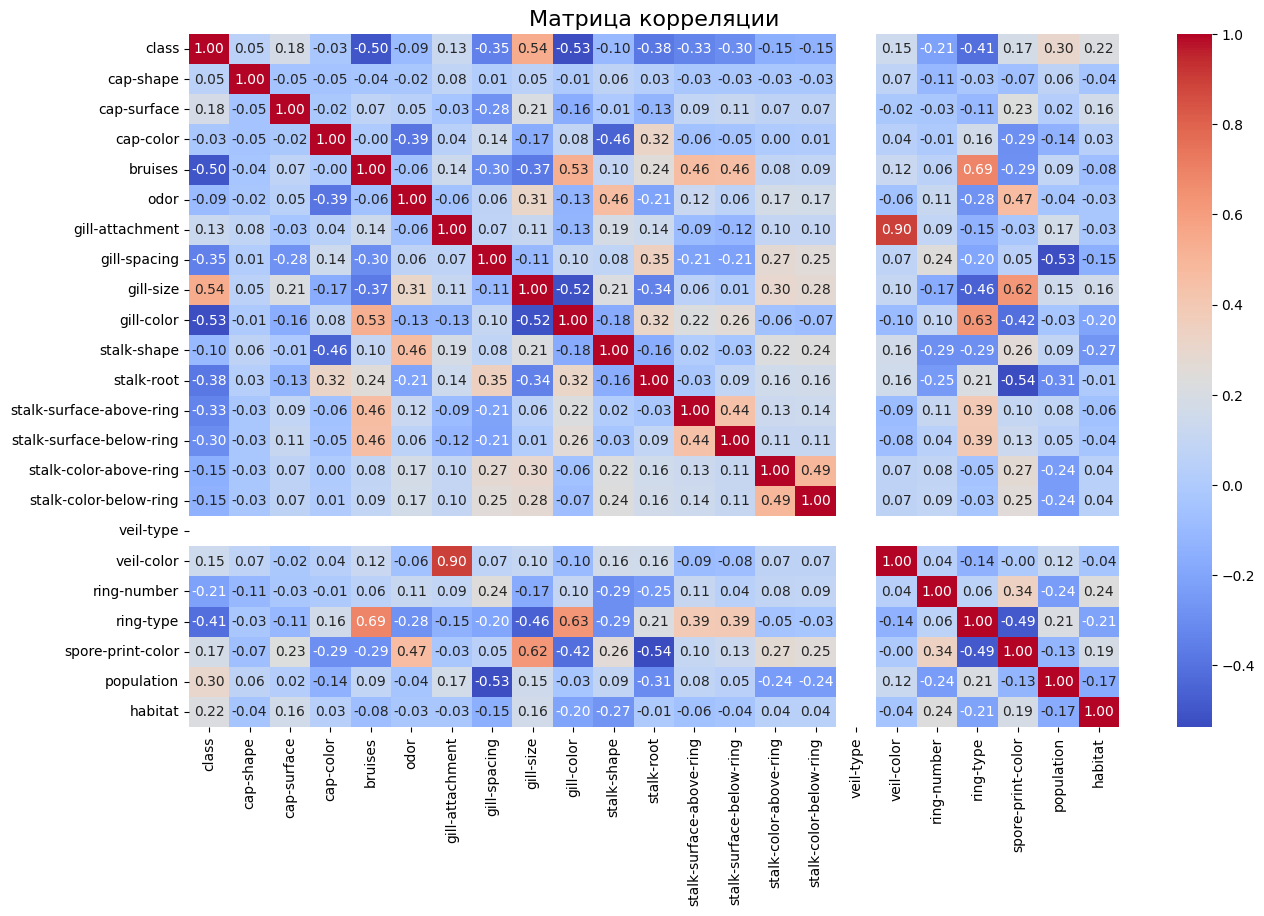

In [5]:
corr_matrix = df.corr()

# 3. Визуализация матрицы корреляции
plt.figure(figsize=(15,9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Матрица корреляции", fontsize=16)
plt.show()

In [6]:
features_to_drop = ["veil-type", "veil-color"]

# Разделяем признаки и метки
X = df.drop(features_to_drop + ["class"], axis=1)
y = df["class"]

In [7]:
# 3. Масштабирование признаков (для UMAP)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

/Users/anastasiakaftancikova/Documents/GitHub/data_science_prof_level/hw2/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/anastasiakaftancikova/Documents/GitHub/data_science_prof_level/hw2/.venv/lib/python3.9/site-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited at iteration 2000 with accuracies 
[1.50743005e-14 1.33107723e-06 1.58972117e-06 3.87895208e-06]
not reaching the requested tolerance 2.1010637283325195e-06.
Use iteration 1933 instead with accuracy 
8.849147598575185e-07.

  _, diffusion_map = lobpcg(
/Users/anastasiakaftancikova/Documents/GitHub/data_science_prof_level/hw2/.venv/lib/python3.9/site-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited postprocessing with accuracies 
[5.69950720e-15 7.61747122e-07 6.71333512e-07 2.10657833e-06]
not reaching the requested tolerance 2.1010637283325195e-06.
  _, diffusi

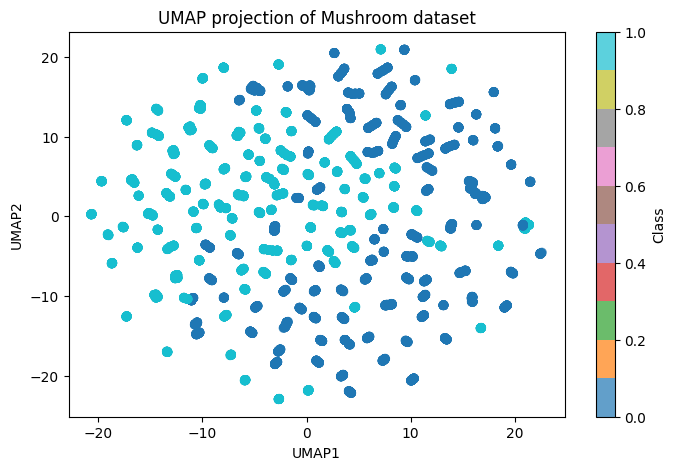

In [8]:
# 4. UMAP
umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)

# Визуализация UMAP
plt.figure(figsize=(8,5))
plt.scatter(X_umap[:,0], X_umap[:,1], c=y, cmap='tab10', alpha=0.7)
plt.title("UMAP projection of Mushroom dataset")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(label='Class')
plt.show()

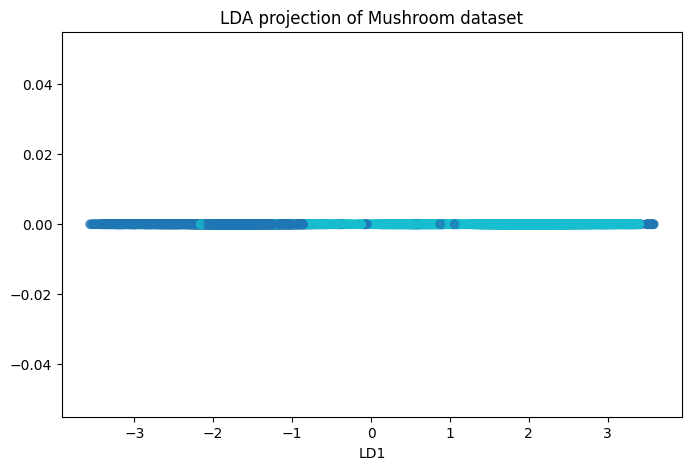

In [9]:
# 5. LDA
# LDA: n_components <= num_classes - 1
lda_model = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda_model.fit_transform(X, y)

# Визуализация LDA
plt.figure(figsize=(8,5))
plt.scatter(X_lda[:,0], np.zeros_like(X_lda[:,0]), c=y, cmap='tab10', alpha=0.7)
plt.title("LDA projection of Mushroom dataset")
plt.xlabel("LD1")
plt.show()

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



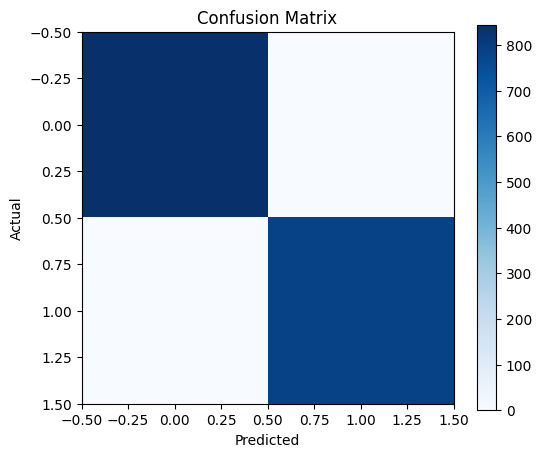

In [10]:
# 6. Классификация (RandomForest)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()